# 📈 RL Trading Agent — Single Asset (NIFTY 50 / NSE)

**Project:** Reinforcement Learning — B.Tech Data Science, Sem VII

A PPO-based RL agent trained to trade a single Indian equity asset using historical OHLCV data.
The agent learns a buy/hold/sell policy from price + technical indicator observations.

---
**Pipeline:** Data → Features → Custom Gym Env → PPO Training → Evaluation

**Outputs:**
- Stock price chart with BUY/SELL markers
- PPO vs Random Agent vs Buy-and-Hold cumulative returns
- Train vs Test performance comparison
- Metrics table: Total Return, Sharpe Ratio, Max Drawdown, No. of Trades

In [1]:
# ─────────────────────────────────────────────
# CELL 2 — CONFIG (Change asset/dates here)
# ─────────────────────────────────────────────

CONFIG = {
    "ticker":       "ADANIENT.NS",          
    "start_date":   "2019-01-01",     # 5 years of data
    "end_date":     "2024-01-01",
    "train_split":  0.80,             # 80% train, 20% test
    "timesteps":    75_000,           # PPO training steps (~2 min on CPU)
    "initial_cash": 100_000,          # Starting portfolio value (₹)
    "window_size":  20,               # Lookback window for observations
    "random_seed":  42,
}

print("CONFIG loaded:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

CONFIG loaded:
  ticker: ADANIENT.NS
  start_date: 2019-01-01
  end_date: 2024-01-01
  train_split: 0.8
  timesteps: 75000
  initial_cash: 100000
  window_size: 20
  random_seed: 42


---
## Section 1 — Data Download

We pull 5 years of daily OHLCV (Open, High, Low, Close, Volume) data for the chosen asset using `yfinance`.
This gives us ~1250 trading days — enough for meaningful train/test split.

In [2]:
# ─────────────────────────────────────────────
# CELL 3 — Download OHLCV Data
# ─────────────────────────────────────────────

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Download data
print(f"Downloading {CONFIG['ticker']} from {CONFIG['start_date']} to {CONFIG['end_date']}...")
raw = yf.download(
    CONFIG['ticker'],
    start=CONFIG['start_date'],
    end=CONFIG['end_date'],
    progress=False
)

# Flatten MultiIndex columns if present (yfinance quirk)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

# Keep only standard OHLCV columns
df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.dropna(inplace=True)
df.index = pd.to_datetime(df.index)

print(f"✅ Downloaded {len(df)} trading days")
print(f"   Date range: {df.index[0].date()} → {df.index[-1].date()}")
print(f"   Close range: {df['Close'].min():.0f} → {df['Close'].max():.0f}")
df.tail(3)

✅ Downloaded 1235 trading days
   Date range: 2019-01-01 → 2023-12-29
   Close range: 116 → 4160


Price,Open,High,Low,Close,Volume
Date,,,,,
2023-12-27,2878.147324,2892.234927,2831.089206,2840.830566,1698325
2023-12-28,2852.470044,2864.809198,2797.618792,2807.409912,4102912
2023-12-29,2821.397685,2860.762919,2800.366532,2846.425537,1507086


---
## Section 2 — Feature Engineering

We enrich the raw OHLCV data with 4 technical indicators:
- **MA20 / MA50** — Trend direction (short vs long-term moving average)
- **RSI (14)** — Momentum oscillator; >70 = overbought, <30 = oversold
- **MACD Line** — Trend momentum; crossovers signal buy/sell

These are fed as part of the observation vector to the RL agent.

In [3]:
# ─────────────────────────────────────────────
# CELL 4 — Technical Indicators
# ─────────────────────────────────────────────

import pandas_ta as ta

# 20-day and 50-day Simple Moving Averages
df['MA20'] = ta.sma(df['Close'], length=20)
df['MA50'] = ta.sma(df['Close'], length=50)

# 14-day RSI
df['RSI'] = ta.rsi(df['Close'], length=14)

# MACD line (12-26-9 default)
macd_df = ta.macd(df['Close'], fast=12, slow=26, signal=9)
df['MACD'] = macd_df['MACD_12_26_9']

# Drop NaN rows created by indicator lookback periods
df.dropna(inplace=True)

print(f"✅ Features added. Dataset: {len(df)} rows after dropping NaNs")
print(f"   Columns: {list(df.columns)}")
df[['Close', 'MA20', 'MA50', 'RSI', 'MACD']].tail(3)

✅ Features added. Dataset: 1186 rows after dropping NaNs
   Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'MA20', 'MA50', 'RSI', 'MACD']


Price,Close,MA20,MA50,RSI,MACD
Date,,,,,
2023-12-27,2840.830566,2782.462207,2474.926938,60.608077,119.175594
2023-12-28,2807.409912,2803.108887,2482.027637,57.765254,109.086653
2023-12-29,2846.425537,2827.607166,2490.412197,60.117128,103.051416


In [4]:
# ─────────────────────────────────────────────
# CELL 5 — Train / Test Split
# ─────────────────────────────────────────────

split_idx = int(len(df) * CONFIG['train_split'])

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print(f"Train: {len(train_df)} days  ({train_df.index[0].date()} → {train_df.index[-1].date()})")
print(f"Test:  {len(test_df)} days   ({test_df.index[0].date()} → {test_df.index[-1].date()})")
print()
print("⚠️  No data from test period is used during training (no lookahead leakage).")

Train: 948 days  (2019-03-13 → 2023-01-10)
Test:  238 days   (2023-01-11 → 2023-12-29)

⚠️  No data from test period is used during training (no lookahead leakage).


---
## Section 3 — Custom Trading Environment

We build a custom `gymnasium`-compatible environment (instead of gym-anytrading, which has dependency issues).

**MDP formulation:**
- **State:** Sliding window of [Close, MA20, MA50, RSI, MACD] over last N days
- **Action:** 0 = Hold, 1 = Buy, 2 = Sell
- **Reward:** Change in portfolio value at each step
- **Episode:** One pass through the entire price series

In [5]:
# ─────────────────────────────────────────────
# CELL 6 — Custom Gym Trading Environment
# ─────────────────────────────────────────────

import gymnasium as gym
from gymnasium import spaces

class TradingEnv(gym.Env):
    """
    Single-asset trading environment.
    Actions: 0=Hold, 1=Buy, 2=Sell
    Observation: Normalized window of [Close, MA20, MA50, RSI, MACD]
    """

    metadata = {'render_modes': []}

    def __init__(self, data: pd.DataFrame, window_size: int = 20, initial_cash: float = 100_000):
        super().__init__()

        self.data         = data.reset_index(drop=True)
        self.window_size  = window_size
        self.initial_cash = initial_cash

        # Features used in observation
        self.feature_cols = ['Close', 'MA20', 'MA50', 'RSI', 'MACD']
        self.n_features   = len(self.feature_cols)

        # Action space: 0=Hold, 1=Buy, 2=Sell
        self.action_space = spaces.Discrete(3)

        # Observation space: flattened window of features (all normalized to [-1, 1])
        self.observation_space = spaces.Box(
            low=-5.0, high=5.0,
            shape=(window_size * self.n_features,),
            dtype=np.float32
        )

        # Precompute feature normalization (mean/std per column)
        self._means = self.data[self.feature_cols].mean()
        self._stds  = self.data[self.feature_cols].std().replace(0, 1)  # avoid div by zero

        # Internal trade log (used for evaluation)
        self.trade_log = []

    def _get_obs(self):
        """Return normalized observation window as flat numpy array."""
        window = self.data[self.feature_cols].iloc[
            self.current_step - self.window_size : self.current_step
        ]
        normed = (window - self._means) / self._stds
        return normed.values.flatten().astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size   # start after first window
        self.cash         = self.initial_cash
        self.shares       = 0
        self.portfolio_val = self.initial_cash
        self.trade_log    = []
        return self._get_obs(), {}

    def step(self, action):
        current_price = float(self.data['Close'].iloc[self.current_step])
        prev_portfolio = self.portfolio_val

        # Execute action
        if action == 1 and self.cash >= current_price:      # BUY
            shares_to_buy = int(self.cash // current_price)
            self.shares  += shares_to_buy
            self.cash    -= shares_to_buy * current_price
            self.trade_log.append(('BUY', self.current_step, current_price))

        elif action == 2 and self.shares > 0:               # SELL
            self.cash   += self.shares * current_price
            self.trade_log.append(('SELL', self.current_step, current_price))
            self.shares  = 0

        # Update portfolio value
        self.portfolio_val = self.cash + self.shares * current_price

        # Reward = % change in portfolio value
        reward = (self.portfolio_val - prev_portfolio) / prev_portfolio

        # Advance step
        self.current_step += 1
        terminated = self.current_step >= len(self.data) - 1
        truncated  = False

        return self._get_obs(), reward, terminated, truncated, {}

    def get_portfolio_values(self):
        """Replay all steps and return portfolio value at each step (for plotting)."""
        values = []
        cash, shares = self.initial_cash, 0
        # Replay using trade log
        trade_dict = {step: (action, price) for action, step, price in self.trade_log}
        for i in range(self.window_size, len(self.data)):
            price = float(self.data['Close'].iloc[i])
            if i in trade_dict:
                action, _ = trade_dict[i]
                if action == 'BUY' and cash >= price:
                    s = int(cash // price)
                    shares += s; cash -= s * price
                elif action == 'SELL' and shares > 0:
                    cash += shares * price; shares = 0
            values.append(cash + shares * price)
        return values

print("✅ TradingEnv defined")

# Quick sanity check
env_test = TradingEnv(train_df, CONFIG['window_size'], CONFIG['initial_cash'])
obs, _ = env_test.reset()
print(f"   Obs shape: {obs.shape}  | Action space: {env_test.action_space}")

✅ TradingEnv defined
   Obs shape: (100,)  | Action space: Discrete(3)


---
## Section 4 — PPO Agent Training

We use **Proximal Policy Optimization (PPO)** from Stable-Baselines3.
PPO is an on-policy actor-critic algorithm that clips the policy update to prevent destructive large updates.

The policy network is a simple **MLP** (default in SB3) — no LSTM or Transformer.

Training runs for ~75,000 timesteps on the training window only.

In [6]:
# ─────────────────────────────────────────────
# CELL 7 — Train PPO Agent
# ─────────────────────────────────────────────

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
import time

# Callback to track reward during training
class RewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.rewards = []
        self.ep_reward = 0

    def _on_step(self):
        self.ep_reward += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            self.rewards.append(self.ep_reward)
            self.ep_reward = 0
        return True

# Create training environment
train_env = TradingEnv(train_df, CONFIG['window_size'], CONFIG['initial_cash'])

# Instantiate PPO with MLP policy
model = PPO(
    policy         = 'MlpPolicy',
    env            = train_env,
    learning_rate  = 3e-4,
    n_steps        = 2048,
    batch_size     = 64,
    n_epochs       = 10,
    gamma          = 0.99,          # discount factor
    gae_lambda     = 0.95,          # GAE smoothing
    clip_range     = 0.2,           # PPO clip epsilon
    verbose        = 0,
    seed           = CONFIG['random_seed'],
    device         = 'cpu'
)

reward_logger = RewardLogger()

print(f"🚀 Training PPO for {CONFIG['timesteps']:,} timesteps...")
t0 = time.time()

model.learn(
    total_timesteps = CONFIG['timesteps'],
    callback        = reward_logger,
    progress_bar    = True
)

elapsed = time.time() - t0
print(f"\n✅ Training complete in {elapsed:.1f}s")
print(f"   Episodes completed: {len(reward_logger.rewards)}")

# Save model
model.save("ppo_trading_agent")
print("   Model saved → ppo_trading_agent.zip")

🚀 Training PPO for 75,000 timesteps...



✅ Training complete in 162.1s
   Episodes completed: 81
   Model saved → ppo_trading_agent.zip


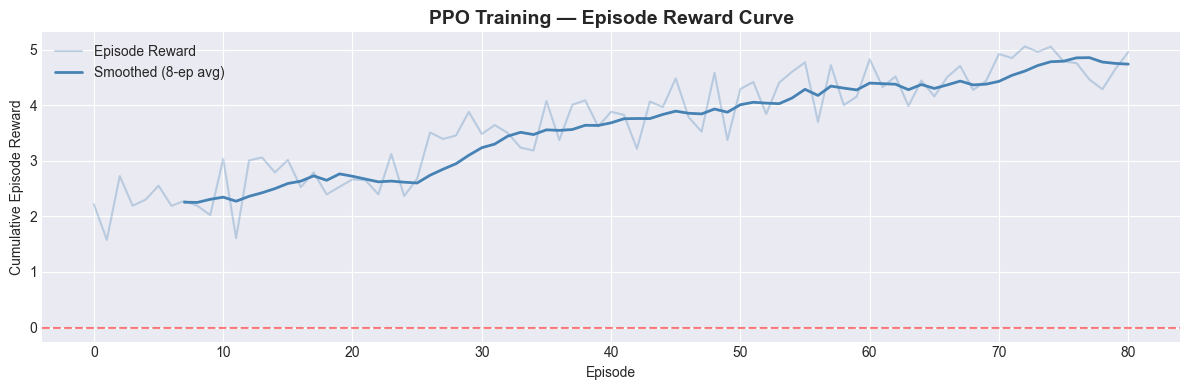

📊 Reward curve saved → reward_curve.png


In [7]:
# ─────────────────────────────────────────────
# CELL 8 — Training Reward Curve
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-darkgrid')

rewards = reward_logger.rewards

# Smooth reward curve with rolling average
window = max(1, len(rewards) // 10)
smoothed = pd.Series(rewards).rolling(window).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rewards, alpha=0.3, color='steelblue', label='Episode Reward')
ax.plot(smoothed, color='steelblue', lw=2, label=f'Smoothed ({window}-ep avg)')
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_title('PPO Training — Episode Reward Curve', fontsize=14, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative Episode Reward')
ax.legend()
plt.tight_layout()
plt.savefig('reward_curve.png', dpi=150)
plt.show()
print("📊 Reward curve saved → reward_curve.png")

---
## Section 5 — Evaluation

We evaluate on the **held-out test set** (data the agent never saw during training).

We compare 3 strategies:
1. **PPO Agent** — our trained RL agent
2. **Random Agent** — takes random buy/hold/sell actions (baseline sanity check)
3. **Buy & Hold** — buys on day 1, holds until last day (passive benchmark)

Then report: Total Return %, Sharpe Ratio, Max Drawdown, No. of Trades.

In [8]:
# ─────────────────────────────────────────────
# CELL 9 — Run Agent on Test Set
# ─────────────────────────────────────────────

def run_agent(env, model=None, deterministic=True):
    """
    Run one episode on the given env.
    If model=None → random agent.
    Returns portfolio values list and trade log.
    """
    obs, _ = env.reset()
    portfolio_vals = [env.portfolio_val]
    done = False

    while not done:
        if model is not None:
            action, _ = model.predict(obs, deterministic=deterministic)
        else:
            action = env.action_space.sample()  # random
        obs, reward, terminated, truncated, _ = env.step(action)
        portfolio_vals.append(env.portfolio_val)
        done = terminated or truncated

    return portfolio_vals, env.trade_log

# Test environments
test_env_ppo    = TradingEnv(test_df, CONFIG['window_size'], CONFIG['initial_cash'])
test_env_random = TradingEnv(test_df, CONFIG['window_size'], CONFIG['initial_cash'])

# Run agents
ppo_vals,    ppo_trades    = run_agent(test_env_ppo, model=model)
random_vals, random_trades = run_agent(test_env_random, model=None)

# Buy & Hold benchmark
test_close = test_df['Close'].values
bh_shares  = CONFIG['initial_cash'] // test_close[0]
bh_cash    = CONFIG['initial_cash'] - bh_shares * test_close[0]
bh_vals    = [bh_cash + bh_shares * p for p in test_close]

print(f"✅ Evaluation complete")
print(f"   PPO trades:    {len(ppo_trades)}")
print(f"   Random trades: {len(random_trades)}")

✅ Evaluation complete
   PPO trades:    41
   Random trades: 80


In [9]:
# ─────────────────────────────────────────────
# CELL 10 — Metrics Calculation
# ─────────────────────────────────────────────

def compute_metrics(portfolio_vals, initial_cash, label):
    vals = np.array(portfolio_vals)
    returns = np.diff(vals) / vals[:-1]          # daily returns

    total_return = (vals[-1] - initial_cash) / initial_cash * 100

    # Sharpe Ratio (annualized, assuming 252 trading days, risk-free=0)
    sharpe = (returns.mean() / (returns.std() + 1e-9)) * np.sqrt(252)

    # Max Drawdown
    peak     = np.maximum.accumulate(vals)
    drawdown = (vals - peak) / peak
    max_dd   = drawdown.min() * 100

    return {
        'Strategy':       label,
        'Final Value (₹)': f"₹{vals[-1]:,.0f}",
        'Total Return %':  f"{total_return:+.2f}%",
        'Sharpe Ratio':    f"{sharpe:.3f}",
        'Max Drawdown %':  f"{max_dd:.2f}%",
    }

metrics = [
    compute_metrics(ppo_vals,    CONFIG['initial_cash'], 'PPO Agent'),
    compute_metrics(random_vals, CONFIG['initial_cash'], 'Random Agent'),
    compute_metrics(bh_vals,     CONFIG['initial_cash'], 'Buy & Hold'),
]

metrics_df = pd.DataFrame(metrics).set_index('Strategy')
print("\n📊 PERFORMANCE METRICS — TEST SET")
print("=" * 55)
print(metrics_df.to_string())
print("=" * 55)
print(f"   No. of PPO Trades: {len(ppo_trades)}")
print("\n⚠️  Results are backtested. Past performance ≠ future returns.")


📊 PERFORMANCE METRICS — TEST SET
             Final Value (₹) Total Return % Sharpe Ratio Max Drawdown %
Strategy                                                               
PPO Agent            ₹93,785         -6.22%       -0.051        -32.00%
Random Agent        ₹145,330        +45.33%        1.254        -18.52%
Buy & Hold           ₹78,821        -21.18%        0.048        -66.62%
   No. of PPO Trades: 41

⚠️  Results are backtested. Past performance ≠ future returns.


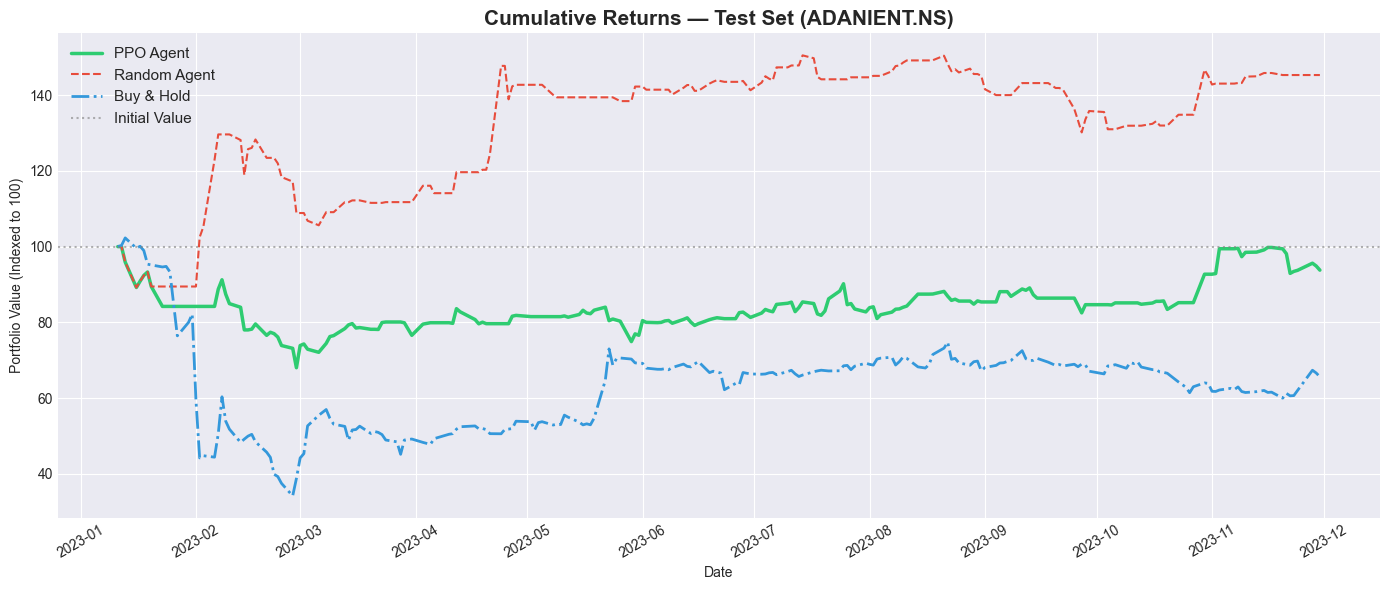

📊 Saved → cumulative_returns.png


In [10]:
# ─────────────────────────────────────────────
# CELL 11 — PLOT 1: Cumulative Returns Comparison
#            PPO vs Random vs Buy & Hold
# ─────────────────────────────────────────────

def normalize(vals):
    """Normalize to start at 100 for apples-to-apples comparison."""
    return np.array(vals) / vals[0] * 100

min_len = min(len(ppo_vals), len(random_vals), len(bh_vals))
test_dates = test_df.index[:min_len]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_dates, normalize(ppo_vals[:min_len]),    color='#2ecc71', lw=2.5, label='PPO Agent')
ax.plot(test_dates, normalize(random_vals[:min_len]), color='#e74c3c', lw=1.5, linestyle='--', label='Random Agent')
ax.plot(test_dates, normalize(bh_vals[:min_len]),     color='#3498db', lw=2,   linestyle='-.',  label='Buy & Hold')
ax.axhline(100, color='gray', linestyle=':', alpha=0.6, label='Initial Value')

ax.set_title(f'Cumulative Returns — Test Set ({CONFIG["ticker"]})', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (Indexed to 100)')
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('cumulative_returns.png', dpi=150)
plt.show()
print("📊 Saved → cumulative_returns.png")

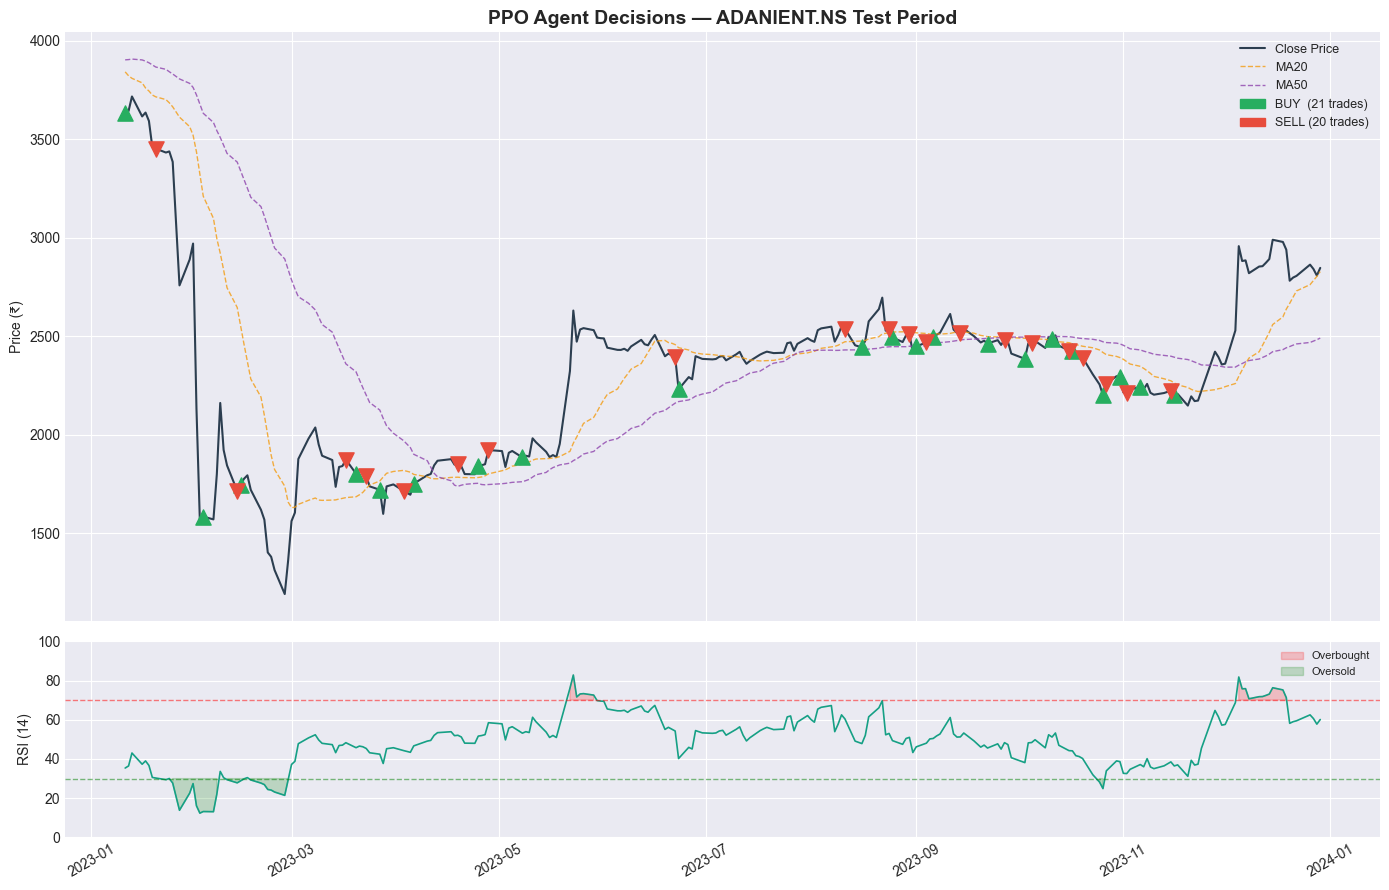

📊 Saved → buy_sell_markers.png


In [11]:
# ─────────────────────────────────────────────
# CELL 12 — PLOT 2: Stock Price + BUY/SELL Markers
#            This is the WOW chart
# ─────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

# --- Top: Price + MAs + Trade Markers ---
ax1.plot(test_df.index, test_df['Close'], color='#2c3e50', lw=1.5, label='Close Price')
ax1.plot(test_df.index, test_df['MA20'],  color='#f39c12', lw=1, linestyle='--', alpha=0.8, label='MA20')
ax1.plot(test_df.index, test_df['MA50'],  color='#8e44ad', lw=1, linestyle='--', alpha=0.8, label='MA50')

# Plot BUY / SELL markers from PPO trade log
buy_steps  = [step for action, step, price in ppo_trades if action == 'BUY']
sell_steps = [step for action, step, price in ppo_trades if action == 'SELL']

# Map steps (env steps) to test_df index positions
# env steps start at window_size; offset accordingly
ws = CONFIG['window_size']

for step in buy_steps:
    idx = step - ws
    if 0 <= idx < len(test_df):
        ax1.scatter(test_df.index[idx], test_df['Close'].iloc[idx],
                    marker='^', color='#27ae60', s=120, zorder=5)

for step in sell_steps:
    idx = step - ws
    if 0 <= idx < len(test_df):
        ax1.scatter(test_df.index[idx], test_df['Close'].iloc[idx],
                    marker='v', color='#e74c3c', s=120, zorder=5)

# Legend with custom markers
buy_patch  = mpatches.Patch(color='#27ae60', label=f'BUY  ({len(buy_steps)} trades)')
sell_patch = mpatches.Patch(color='#e74c3c', label=f'SELL ({len(sell_steps)} trades)')
ax1.legend(handles=[*ax1.get_legend_handles_labels()[0][:3], buy_patch, sell_patch], fontsize=9)
ax1.set_title(f'PPO Agent Decisions — {CONFIG["ticker"]} Test Period', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (₹)')

# --- Bottom: RSI ---
ax2.plot(test_df.index, test_df['RSI'], color='#16a085', lw=1.2)
ax2.axhline(70, color='red',   linestyle='--', alpha=0.5, lw=1)
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, lw=1)
ax2.fill_between(test_df.index, test_df['RSI'], 70,
                  where=(test_df['RSI'] > 70), alpha=0.2, color='red',   label='Overbought')
ax2.fill_between(test_df.index, test_df['RSI'], 30,
                  where=(test_df['RSI'] < 30), alpha=0.2, color='green', label='Oversold')
ax2.set_ylim(0, 100)
ax2.set_ylabel('RSI (14)')
ax2.legend(fontsize=8)
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('buy_sell_markers.png', dpi=150)
plt.show()
print("📊 Saved → buy_sell_markers.png")

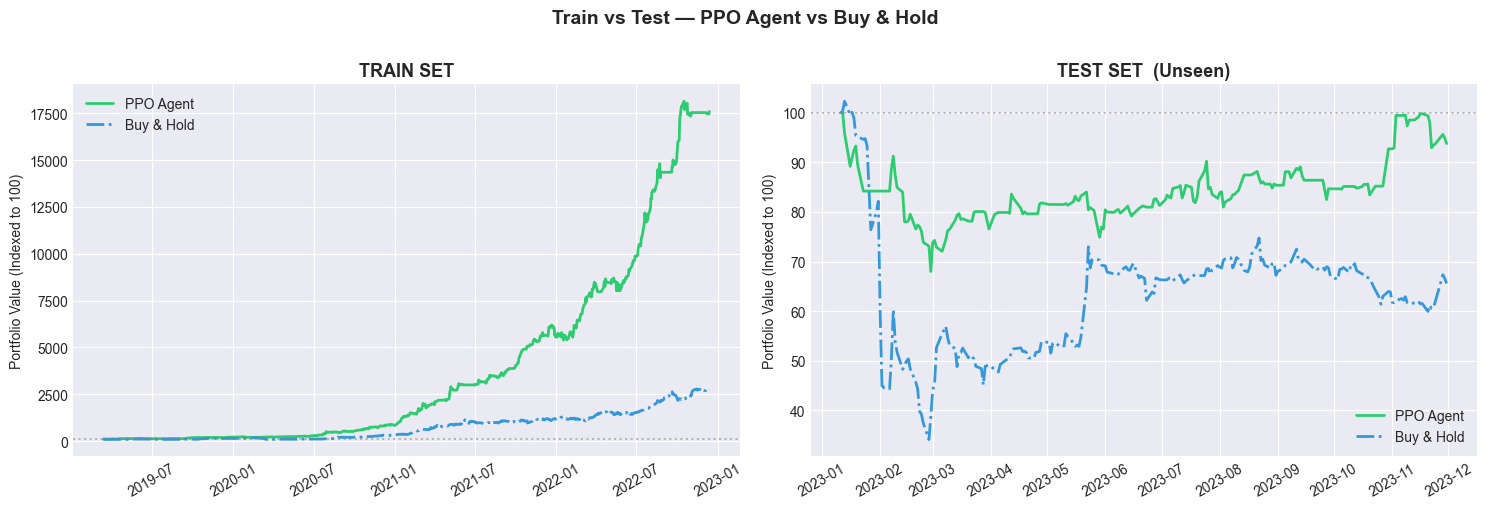

📊 Saved → train_vs_test.png

💡 Note: If Test performance is worse than Train — that's overfitting.
   Next step: Walk-forward validation to get more realistic estimates.


In [12]:
# ─────────────────────────────────────────────
# CELL 13 — PLOT 3: Train vs Test Performance
#            Shows overfitting honestly
# ─────────────────────────────────────────────

# Run agent on training set too
train_env_eval = TradingEnv(train_df, CONFIG['window_size'], CONFIG['initial_cash'])
train_ppo_vals, _ = run_agent(train_env_eval, model=model)

# B&H on train set
train_close = train_df['Close'].values
train_bh_shares = CONFIG['initial_cash'] // train_close[0]
train_bh_cash   = CONFIG['initial_cash'] - train_bh_shares * train_close[0]
train_bh_vals   = [train_bh_cash + train_bh_shares * p for p in train_close]

fig, (ax_train, ax_test) = plt.subplots(1, 2, figsize=(15, 5))

for ax, ppo_v, bh_v, dates, label in [
    (ax_train, train_ppo_vals, train_bh_vals, train_df.index, 'TRAIN SET'),
    (ax_test,  ppo_vals,       bh_vals,       test_df.index,  'TEST SET  (Unseen)'),
]:
    mn = min(len(ppo_v), len(bh_v), len(dates))
    ax.plot(dates[:mn], normalize(ppo_v[:mn]), color='#2ecc71', lw=2, label='PPO Agent')
    ax.plot(dates[:mn], normalize(bh_v[:mn]),  color='#3498db', lw=2, linestyle='-.', label='Buy & Hold')
    ax.axhline(100, color='gray', linestyle=':', alpha=0.5)
    ax.set_title(f'{label}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Portfolio Value (Indexed to 100)')
    ax.legend()
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Train vs Test — PPO Agent vs Buy & Hold', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('train_vs_test.png', dpi=150)
plt.show()
print("📊 Saved → train_vs_test.png")
print()
print("💡 Note: If Test performance is worse than Train — that's overfitting.")
print("   Next step: Walk-forward validation to get more realistic estimates.")

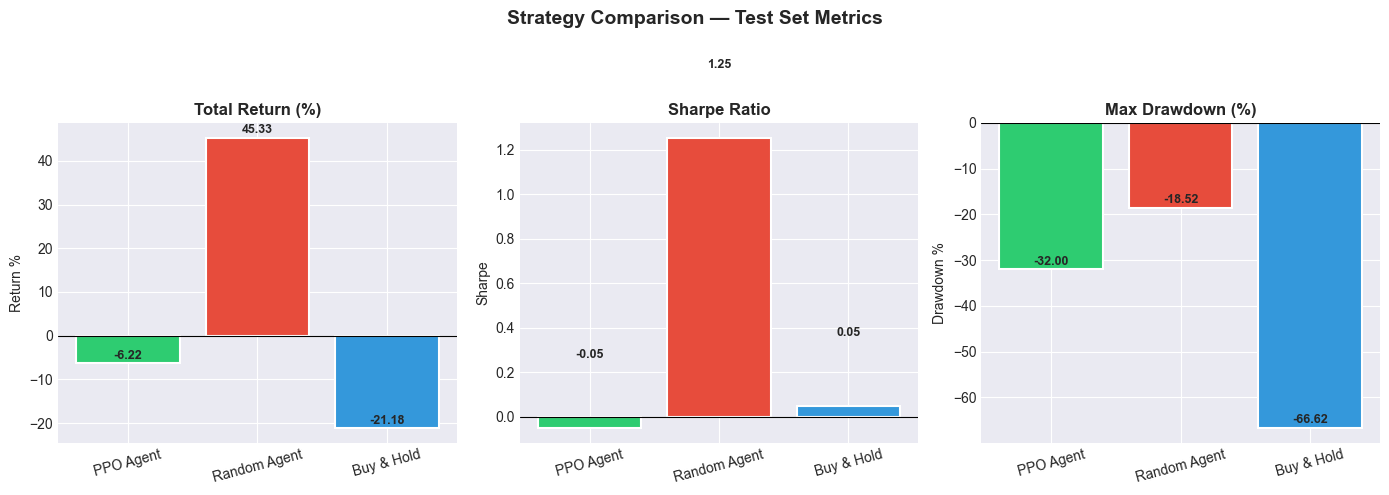

📊 Saved → metrics_bar.png


In [13]:
# ─────────────────────────────────────────────
# CELL 14 — PLOT 4: Metrics Bar Chart
#            Sharpe + Return side by side
# ─────────────────────────────────────────────

def raw_metrics(portfolio_vals, initial_cash):
    vals    = np.array(portfolio_vals)
    returns = np.diff(vals) / vals[:-1]
    total_r = (vals[-1] - initial_cash) / initial_cash * 100
    sharpe  = (returns.mean() / (returns.std() + 1e-9)) * np.sqrt(252)
    peak    = np.maximum.accumulate(vals)
    max_dd  = ((vals - peak) / peak).min() * 100
    return total_r, sharpe, max_dd

ppo_r,    ppo_s,    ppo_dd    = raw_metrics(ppo_vals,    CONFIG['initial_cash'])
random_r, random_s, random_dd = raw_metrics(random_vals, CONFIG['initial_cash'])
bh_r,     bh_s,     bh_dd     = raw_metrics(bh_vals,     CONFIG['initial_cash'])

strategies = ['PPO Agent', 'Random Agent', 'Buy & Hold']
colors     = ['#2ecc71', '#e74c3c', '#3498db']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, values, title, ylabel in [
    (axes[0], [ppo_r, random_r, bh_r],       'Total Return (%)',    'Return %'),
    (axes[1], [ppo_s, random_s, bh_s],       'Sharpe Ratio',        'Sharpe'),
    (axes[2], [ppo_dd, random_dd, bh_dd],    'Max Drawdown (%)',    'Drawdown %'),
]:
    bars = ax.bar(strategies, values, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color='black', lw=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Strategy Comparison — Test Set Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_bar.png', dpi=150)
plt.show()
print("📊 Saved → metrics_bar.png")

---
## Summary

| Component | Choice | Reason |
|---|---|---|
| Asset | Adani Enterprises | Indian market, liquid, 5yr history |
| Features | Close, MA20, MA50, RSI, MACD | Classic momentum + trend indicators |
| Environment | Custom Gym env | No dependency conflicts, full control |
| Agent | PPO (MLP policy) | Stable, handles continuous obs, clip prevents instability |
| Baseline 1 | Random Agent | Checks if learning > chance |
| Baseline 2 | Buy & Hold | Classic passive benchmark |

### Limitations (honest)
- Results are **backtested** — not forward-looking.
- Daily OHLCV has weak signal; agent likely overfits training window.
- Transaction costs / slippage not modelled.

### Next Steps
- **Walk-forward validation** — rolling train/test windows for more realistic evaluation
- **Reward shaping** — penalize for holding cash too long, reward Sharpe instead of raw return
- **Intraday data** — 15min/1hr candles for richer signal
